In [9]:
from binance.client import Client
import pandas as pd  # Opcional, para verlos bonito en un DataFrame
from datetime import datetime
import math
client = Client()

# Últimos 90 días aproximados en intervalo diario
klines = client.get_historical_klines(
    "BTCUSDT", 
    Client.KLINE_INTERVAL_1HOUR, 
    "360 days ago UTC"  # Binance acepta strings como este
)

listaprecios= []
listaFit=[]
for i in range(len(klines)):
    if(i<math.floor(len(klines)*0.2)):
        listaFit.append(float(klines[i][4]))
    else:
        listaprecios.append(float(klines[i][4]))

print(len(listaprecios))
print(listaFit)

6912
[96409.54, 97417.66, 98391.21, 97461.86, 97248.22, 96319.99, 97632.59, 97106.02, 97304.07, 96734.32, 97281.37, 97832.53, 95473.74, 94811.85, 94359.53, 92723.98, 93941.75, 95204.0, 95627.99, 96991.62, 96727.99, 97206.59, 96993.58, 97116.0, 96451.88, 96623.29, 97463.93, 97805.44, 97525.77, 97357.23, 97396.0, 97487.46, 97588.0, 98691.98, 98726.76, 99040.0, 98650.0, 98565.82, 98131.22, 98262.08, 97131.99, 97344.54, 97083.11, 97527.97, 97292.0, 97595.28, 97400.01, 97269.03, 97456.91, 96892.0, 97147.46, 97291.99, 97253.01, 97060.01, 96719.99, 96994.37, 96076.01, 96156.19, 96739.99, 96210.24, 96534.5, 96940.27, 97009.03, 97101.28, 96987.61, 96976.0, 95363.44, 95377.72, 95715.09, 95612.19, 95955.22, 94836.55, 95592.49, 95203.11, 95547.41, 95186.27, 94390.84, 94449.99, 94723.96, 96025.15, 95832.03, 95608.02, 94824.83, 95404.01, 95503.87, 96013.72, 96392.39, 95932.42, 96305.0, 94924.34, 94389.67, 93250.37, 93980.61, 93364.26, 92758.55, 93044.79, 93186.34, 93964.01, 95191.81, 94881.47, 94550

In [2]:
#ahora tomamtos los primeros 200 datos para calcular los parametros de las bandas de bollinger
#entonces voy a tener 2 listas, 1 para entrenar mi modulo bollinger y otra para ir testeando la estrategia

In [ ]:
from strategies.bollinger import Bollinger
b = Bollinger(listaFit)
listaDeVectoresSobreVenta = []
listaDeVectoresSobreCompra = []
vector = []
for i in range(len(listaprecios)-1):
    print(f"la diferencia entre el valor actual de BTC:{listaprecios[i]} y la banda superior: {b.topBand()} es: \n {listaprecios[i]-b.topBand()}")
    

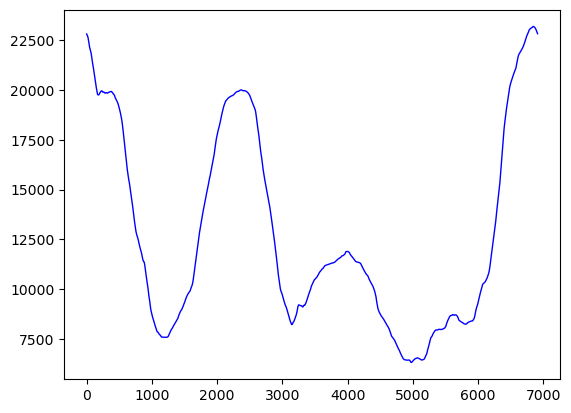

AttributeError: 'list' object has no attribute 'mean'

In [22]:
#grafico la diferencia entre las bandas superior e inferior
import matplotlib.pyplot as plt
import numpy as np
y=[]
x = np.linspace(0,len(listaprecios),len(listaprecios))
for i in range(len(listaprecios)):
    y.append(b.topBand() - b.lowerBand())
    b.updateAtributes(listaprecios[i])
plt.plot(x,y,label="dif bands",color="blue",linewidth=1)
plt.show()


In [27]:
print(np.std(y)/np.mean(y))

0.3912914368174271
